In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

BASE = Path("C:/Users/janku/Documents/KCL/Research Project/Research Project")
METRICS_DIR = BASE / "results" / "metrics"
FIG_DIR = BASE / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_png(fig, filename, dpi=300):
    """Save a matplotlib figure into results/figures and return the path."""
    out_path = FIG_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path


MODEL_FILES = {
    ("RADAR", "Random Forest"): METRICS_DIR / "RF" / "RADAR" / "radar_rf_summary.csv",
    ("RADAR", "MERF"): METRICS_DIR / "MERF" / "RADAR" / "radar_merf_summary.csv",
    ("RADAR", "SVM"): METRICS_DIR / "SVM" / "RADAR" / "radar_svm_cv_summary.csv",
    ("RADAR", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "RADAR" / "radar_xgbc_cv_summary.csv",
    ("RADAR", "Gradient Boosting Regressor"): METRICS_DIR / "GradBoost" / "RADAR" / "Radar_xgb_cv_summary.csv",
    ("RADAR", "GPBoost"): METRICS_DIR / "GradBoost" / "RADAR" / "radar_gpboost_cv_summary.csv",
    ("ANDROIDS", "Random Forest"): METRICS_DIR / "RF" / "ANDROIDS" / "androids_rf_summary.csv",
    ("ANDROIDS", "MERF"): METRICS_DIR / "MERF" / "ANDROIDS" / "androids_merf_summary.csv",
    ("ANDROIDS", "SVM"): METRICS_DIR / "SVM" / "ANDROIDS" / "androids_svm_cv_summary.csv",
    ("ANDROIDS", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gbc_cv_summary.csv",
    ("ANDROIDS", "GPBoost"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gpboost_cv_summary.csv",
}


def load_metric_table(model_files):
    rows = []
    for (dataset, model), csv_path in model_files.items():
        if not csv_path.exists():
            print(f"Missing file: {csv_path}")
            continue

        d = pd.read_csv(csv_path)
        if d.empty:
            print(f"Empty file: {csv_path}")
            continue

        row = d.iloc[0].to_dict()
        row["dataset"] = dataset
        row["model"] = model
        row["source_file"] = str(csv_path)
        rows.append(row)

    return pd.DataFrame(rows)


metrics_df = load_metric_table(MODEL_FILES)

for metric in ["accuracy_mean", "f1_mean", "roc_auc_mean", "mae_mean", "rmse_mean", "r2_mean"]:
    if metric not in metrics_df.columns:
        metrics_df[metric] = np.nan

print(
    metrics_df[
        ["dataset", "model", "accuracy_mean", "f1_mean", "roc_auc_mean", "mae_mean", "rmse_mean", "r2_mean"]
    ]
)

     dataset                         model  accuracy_mean   f1_mean  \
0      RADAR                 Random Forest       0.567117  0.375845   
1      RADAR                          MERF            NaN       NaN   
2      RADAR                           SVM       0.589900  0.184089   
3      RADAR  Gradient Boosting Classifier       0.562709  0.425639   
4      RADAR   Gradient Boosting Regressor       0.569102  0.436250   
5      RADAR                       GPBoost       0.564384  0.229649   
6   ANDROIDS                 Random Forest       0.651919  0.685872   
7   ANDROIDS                          MERF            NaN       NaN   
8   ANDROIDS                           SVM       0.683535  0.755421   
9   ANDROIDS  Gradient Boosting Classifier       0.620159  0.675944   
10  ANDROIDS                       GPBoost       0.569069  0.674403   

    roc_auc_mean  mae_mean  rmse_mean   r2_mean  
0       0.535340       NaN        NaN       NaN  
1            NaN       NaN  36.100895       NaN

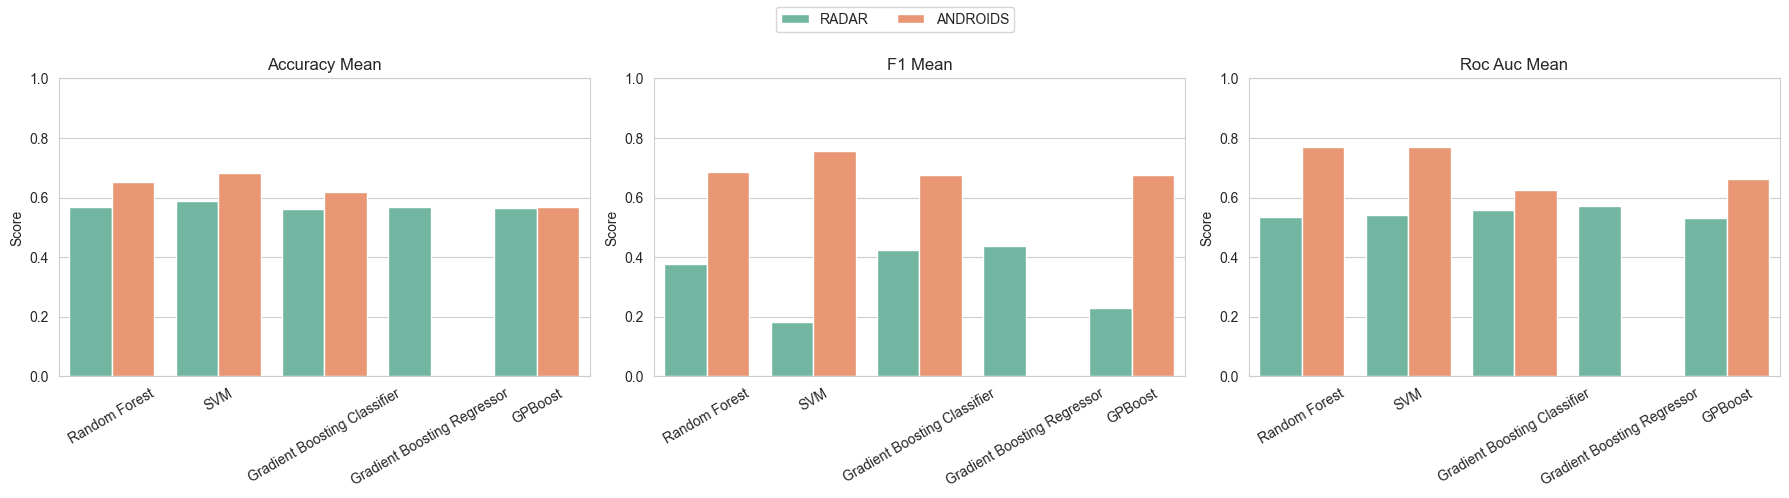

Saved: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\figures\all_models_bar_charts_classification.png


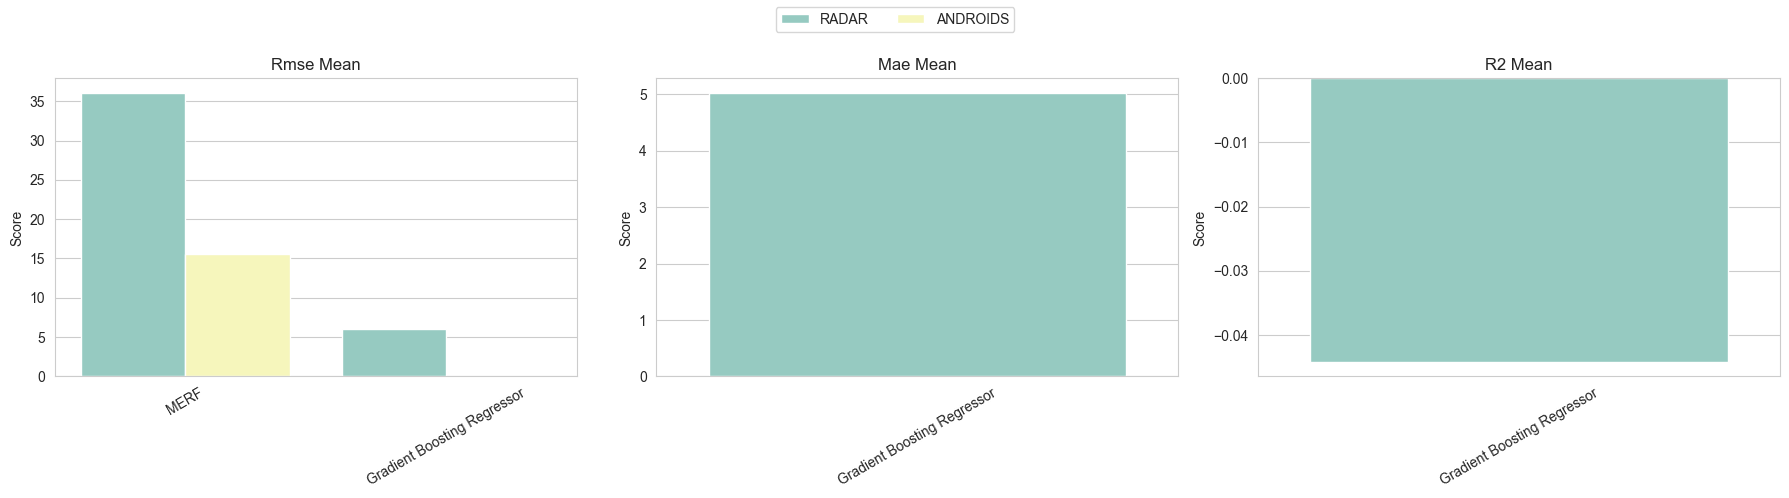

Saved: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\figures\all_models_bar_charts_regression.png


In [5]:
# 1) Bar charts of all models across datasets
# Classification metrics (all classifier-capable models)
classification_metrics = ["accuracy_mean", "f1_mean", "roc_auc_mean"]
fig_cls, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, metric in zip(axes, classification_metrics):
    plot_df = metrics_df[["dataset", "model", metric]].dropna().copy()
    sns.barplot(
        data=plot_df,
        x="model",
        y=metric,
        hue="dataset",
        ax=ax,
        palette="Set2"
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 1)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig_cls.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.92))

bar_cls_path = save_png(fig_cls, "all_models_bar_charts_classification.png")
plt.show()
print(f"Saved: {bar_cls_path}")

# Regression metrics (includes Gradient Boosting Regressor and MERF)
regression_metrics = ["rmse_mean", "mae_mean", "r2_mean"]
fig_reg, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, metric in zip(axes, regression_metrics):
    plot_df = metrics_df[["dataset", "model", metric]].dropna().copy()
    sns.barplot(
        data=plot_df,
        x="model",
        y=metric,
        hue="dataset",
        ax=ax,
        palette="Set3"
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig_reg.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.92))

bar_reg_path = save_png(fig_reg, "all_models_bar_charts_regression.png")
plt.show()
print(f"Saved: {bar_reg_path}")

    dataset                                    pair  delta_accuracy  delta_f1  \
0  ANDROIDS  Gradient Boosting Classifier - GPBoost        0.051090   0.00154   
1     RADAR  Gradient Boosting Classifier - GPBoost       -0.001674   0.19599   

   delta_roc_auc  
0      -0.038149  
1       0.025759  


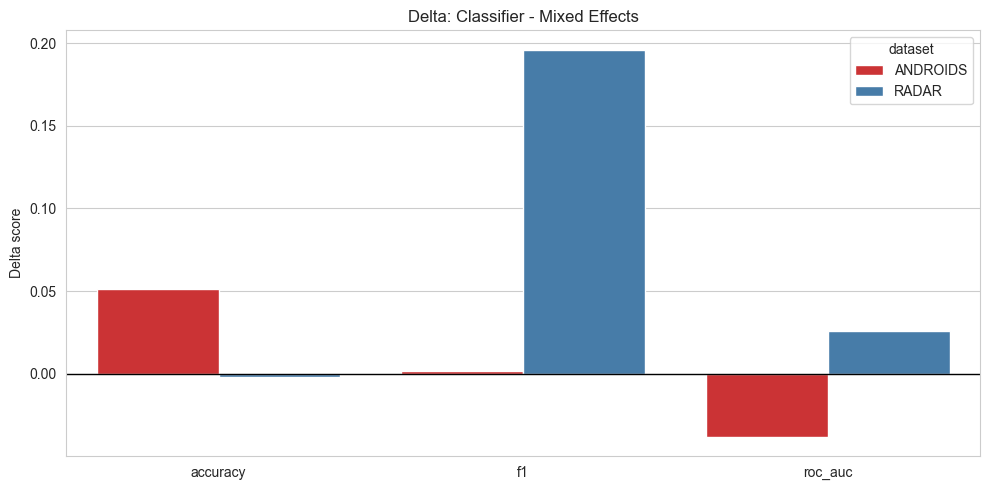

Saved: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\figures\classifier_vs_mixed_effects_delta.png


In [6]:
# 2) Delta comparisons: classifier vs mixed-effects version
pairs = [
    ("Gradient Boosting Classifier", "GPBoost"),
]

delta_rows = []
for dataset in sorted(metrics_df["dataset"].dropna().unique()):
    subset = metrics_df[metrics_df["dataset"] == dataset]

    for classifier_name, mixed_name in pairs:
        c_row = subset[subset["model"] == classifier_name]
        m_row = subset[subset["model"] == mixed_name]
        if c_row.empty or m_row.empty:
            continue

        c_row = c_row.iloc[0]
        m_row = m_row.iloc[0]

        delta_rows.append({
            "dataset": dataset,
            "pair": f"{classifier_name} - {mixed_name}",
            "delta_accuracy": c_row.get("accuracy_mean", np.nan) - m_row.get("accuracy_mean", np.nan),
            "delta_f1": c_row.get("f1_mean", np.nan) - m_row.get("f1_mean", np.nan),
            "delta_roc_auc": c_row.get("roc_auc_mean", np.nan) - m_row.get("roc_auc_mean", np.nan),
        })

delta_df = pd.DataFrame(delta_rows)
print(delta_df)

if not delta_df.empty:
    delta_long = delta_df.melt(
        id_vars=["dataset", "pair"],
        value_vars=["delta_accuracy", "delta_f1", "delta_roc_auc"],
        var_name="metric",
        value_name="delta"
    )
    delta_long["metric"] = delta_long["metric"].str.replace("delta_", "")

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=delta_long,
        x="metric",
        y="delta",
        hue="dataset",
        palette="Set1"
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Delta: Classifier - Mixed Effects")
    plt.xlabel("")
    plt.ylabel("Delta score")
    plt.tight_layout()

    fig = plt.gcf()
    delta_path = save_png(fig, "classifier_vs_mixed_effects_delta.png")
    plt.show()

    print(f"Saved: {delta_path}")
else:
    print("No valid classifier-vs-mixed effects pairs found in metrics_df.")